In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          6.88077495  0.          0.          0.          0.
  0.         -2.78051968  0.          0.          0.          0.
  0.          0.          0.          7.43875894  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          1.79766895  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          2.05011646  0.          0.          0.
  0.          0.        ]


18.167319306406313

# Lasso Stochastic Bandit

# SA Lasso Bandit

In [10]:
from sklearn.linear_model import Lasso

def thresholded_lasso_bandit( T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)
        

        # Perform LASSO regression with lambda using Y_t and X_t
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti_lasso = lasso.coef_  # Estimated beta values
        

        # Define threshold
        threshold = 2 * lamada
    
        # Identify S_0: Indices where |beta| > threshold
        S_0 = np.where(np.abs(beta_esti_lasso) > threshold)[0]
        
        # Identify S_1: Indices where beta > threshold * |S_0| (length of S_0)
        # S_1_threshold = threshold * len(S_0)
        # S_1 = np.where(np.abs(beta_esti_lasso) > S_1_threshold)[0]
        
        # If S_1 is empty, randomly select one feature
        #if len(S_1) == 0:
            #S_1 = [np.random.choice(X_t.shape[1])]

        if len(S_0) == 0:
            S_0 = [np.random.choice(X_t.shape[1])]
    
        # Select features in X_t corresponding to S_1
        X_t_use = X_t[:, S_0]

        # Perform linear regression
        linear_model = LinearRegression(fit_intercept=False)
        linear_model.fit(X_t_use, Y_t)

        # Construct beta estimates
        beta_esti = np.zeros(X_t.shape[1])
        # beta_esti[S_1] = linear_model.coef_
        beta_esti[S_0] = linear_model.coef_

        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-100:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [11]:
def optimization_no_variance(beta_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [12]:
def while_thresholded_lasso_bandit(beta_star):
    L = 1
    error_std = 1
    C_max_wave = 1
    t = 2
    T = 1000 + 2
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    # Print outputs for verification
    print("X:\n", X_t.shape)
    print("Y:\n", Y_t.shape)
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = thresholded_lasso_bandit(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [13]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_thresholded_lasso_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

X:
 (2, 50)
Y:
 (2,)
parameter square error:13.297676071420579
time 2: mean reward 14.468694901061404
parameter square error:18.858087881569418
time 3: mean reward 5.464796792869592
parameter square error:24.70063775618952
time 4: mean reward 6.2823072863993055
parameter square error:14.51523769273549
time 5: mean reward 8.772218271921766
parameter square error:19.459848888401137
time 6: mean reward 8.245497195270826
parameter square error:22.198235860432373
time 7: mean reward 5.699132171333921
parameter square error:15.66692913883381
time 8: mean reward 4.373569885471669
parameter square error:15.473496597891254
time 9: mean reward 5.597139780739127
parameter square error:14.223654398634602
time 10: mean reward 10.918853045873632
parameter square error:13.893177774905556
time 11: mean reward 5.959506696424452
parameter square error:16.10255108860539
time 12: mean reward 6.278247455044694
parameter square error:15.167323493897378
time 13: mean reward 3.5241616546105607
parameter squar

In [14]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   9.6579392    19.68640854   28.39682815 ... 3957.51540031 3961.50863769
 3964.89643301]
Cumulative Regret Std: [  4.55619433   7.11533472   8.19922747 ... 420.9814779  421.33565968
 421.85857573]
L2 Error Parameter Mean: [15.48129418 17.45909615 19.78099712 14.83304616 15.10845257 15.27937025
 14.32671329 14.03643503 14.37425665 12.8066893  13.63575461 14.30772266
 14.11494224 13.69871691 13.45227658 12.48069056 12.78993775 12.1422835
 12.653753   12.64728138 11.99545396 11.79060541 11.82763836 11.36769991
 10.74030007 10.70647455 10.69089008 10.72445806 10.70490912 10.68299021
 10.67255653 10.09335086 10.07678435 10.05451669 10.0555135  10.04430903
 10.04472762 10.02581753 10.02181555 10.00361301  9.97794302  9.97577424
  9.99066557 10.01030452 10.01461529 10.01160509  9.99275892  9.99811606
  9.9712378   9.95951918  9.94903757  9.93692077  9.93768603  9.93653707
  9.94372523  9.94789438  9.95784809  9.96042448  9.95840564  9.95272936
  9.94654212  9.9475844

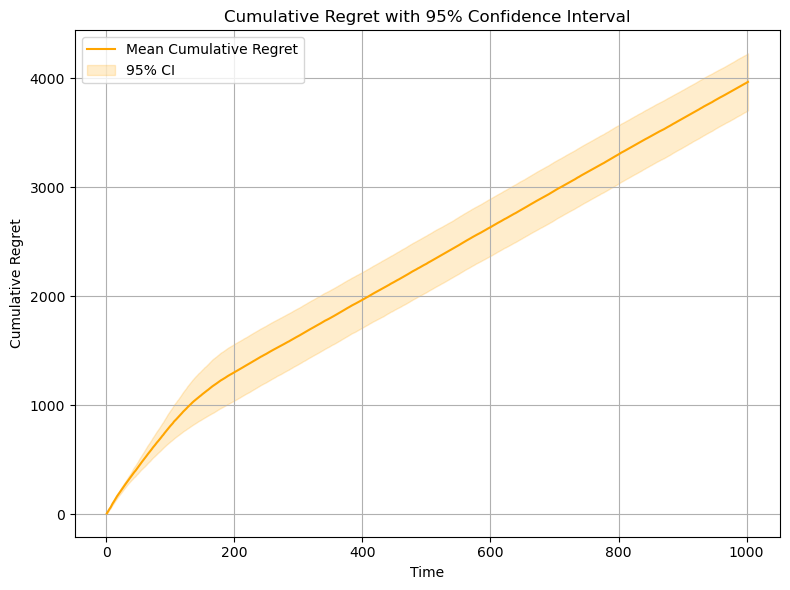

In [15]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [16]:
np.save('cumulative_regret_thresholded-lasso-bandit-d50-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_thresholded-lasso-bandit-d50-s5_10times.npy', l_2_error_parameter_times)